# Projekt: Przewidywanie awarii maszyn (Predictive Maintenance)
## Część 1: Wybór zbioru danych i wstępny import

### Wybór zbioru i uzasadnienie:
Wybraliśmy zbiór danych **AI4I 2020 Predictive Maintenance Dataset**. Jest to syntetyczny zbiór danych odzwierciedlający realne parametry z czujników maszyn przemysłowych (frezarek).

**Dlaczego ten zbiór?**
1. **Adekwatność do problemu:** Zawiera zarówno parametry ciągłe (temperatura, obroty), jak i flagę awarii. Idealnie nadaje się do metod sztucznej inteligencji (klasyfikacja binarna).
2. **Kontekst biznesowy:** Pozwala na rozwiązanie realnego problemu – zamiast naprawiać maszynę, gdy już się zepsuje model ma nas ostrzec wcześniej.


In [ ]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"


df = pd.read_csv(url)


df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:

print("INFORMACJE O TYPACH ZMIENNYCH")
df.info()
print("ANALIZA BRAKÓW W DANYCH")
missing_values = df.isnull().sum()
print(missing_values)

INFORMACJE O TYPACH ZMIENNYCH
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64 

### Słownik Danych (Opis zmiennych telemetrycznych)

Zbiór danych AI4I 2020 symuluje parametry pracy przemysłowej frezarki (maszyny CNC). Poniżej znajduje się fizyczna i biznesowa interpretacja poszczególnych cech (kolumn), z którymi będziemy pracować:

* **Type (Klasa jakości maszyny):** Zmienna kategoryczna określająca jakość wykonania maszyny. Przyjmuje wartości: L-Low,M-Medium,H-High Maszyny niższej jakości są z reguły bardziej podatne na usterki.
* **Air temperature [K] (Temperatura otoczenia):** Temperatura powietrza panująca w hali produkcyjnej. Podana jest w Kelwinach (aby przeliczyć ją na stopnie Celsjusza, należy odjąć 273.15, co oznacza, że średnia temperatura w hali wynosi około 27°C).
* **Process temperature [K] (Temperatura procesu):** Temperatura samego wrzeciona maszyny i strefy obróbki metalu. W wyniku tarcia jest ona zawsze o kilka stopni wyższa niż temperatura otoczenia.
* **Rotational speed [rpm] (Prędkość obrotowa):** Liczba obrotów wrzeciona (z zamontowanym narzędziem tnącym) na minutę. Wysokie obroty są wymagane przy precyzyjnej obróbce, ale mogą generować wyższe temperatury.
* **Torque [Nm] (Moment obrotowy):** "Siła skręcająca" układu napędowego. Wskazuje, z jakim oporem materiału musi radzić sobie maszyna. Nagły wzrost momentu obrotowego często świadczy o tępym narzędziu lub zbyt twardym materiale.
* **Tool wear [min] (Zużycie narzędzia):** Skumulowany czas pracy (w minutach) aktualnie zamontowanego narzędzia tnącego (np. frezu). Im dłuższy czas, tym narzędzie jest bardziej stępione, co drastycznie obciąża maszynę i prowadzi do awarii.
* **Machine failure (Awaria maszyny):** Nasza zmienna docelowa (Target / Zmienna objaśniana). Klasa **0** oznacza prawidłową pracę, natomiast **1** oznacza wystąpienie krytycznej usterki, która zatrzymała proces produkcyjny.

**Wniosek z weryfikacji zbioru:**
Zbiór składa się z 10 000 wierszy i 14 kolumn. Dane są w 100% kompletne – funkcja `isnull()` nie wykryła żadnych braków (NaN). Dzięki temu możemy pominąć etap uzupełniania danych i od razu przejść do selekcji cech.


### Selekcja cech i zapobieganie zjawisku wycieku danych

Przed przystąpieniem do głębszej analizy statystycznej, musimy oczyścić zbiór z kolumn, które mogłyby zaburzyć proces uczenia modelu:

1. **Usunięcie identyfikatorów :**
   Kolumny `UDI` oraz `Product ID` to unikalne kody  maszyn. Algorytmy sztucznej inteligencji opierają się na matematyce – szukanie wzorców w losowych identyfikatorach mogłoby prowadzić do przeuczenia modelu.

2. **Pułapka wycieku danych **
   Naszym zadaniem jest przewidywanie awarii (`Machine failure`). Zbiór zawiera jednak 5 dodatkowych kolumn na samym końcu (`TWF`, `HDF`, `PWF`, `OSF`, `RNQ`), które są flagami informującymi o *konkretnej przyczynie* awarii (np. HDF to przegrzanie).
   Zostawienie ich w zbiorze treningowym doprowadziłoby do tzw. **wycieku danych**. W rzeczywistości produkcyjnej, przed wystąpieniem awarii, nie mamy informacji o tym, z jakiego powodu ona nastąpi. Wpuszczenie tych kolumn do modelu sprawiłoby, że model "oszukiwałby", mając informacje z przyszłości.

Zostawiamy wyłącznie "czyste" parametry z czujników maszyn (temperatura, obroty, moment obrotowy, zużycie narzędzia) oraz flagę awarii.

In [ ]:

kolumny_do_usuniecia = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


df = df.drop(columns=kolumny_do_usuniecia, errors='ignore')

print("Kolumny pozostawione do analizy i modelowania:")
print(df.columns.tolist())

Kolumny pozostawione do analizy i modelowania:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']




Przed budową modeli sprawdzamy zakresy wartości dla poszczególnych czujników (m.in. średnią, wartości minimalne i maksymalne). Pozwala to wykryć ewentualne anomalie fizyczne (np. ujemną temperaturę w Kelwinach, co oznaczałoby błąd czujnika).

Następnie badamy rozkład zmiennej docelowej (`Machine failure`). W przypadku danych przemysłowych awarie są zazwyczaj zdarzeniami rzadkimi, co prowadzi do problemu niezbalansowanych klas (Imbalanced Data).

=== STATYSTYKI OPISOWE CZUJNIKÓW ===


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0


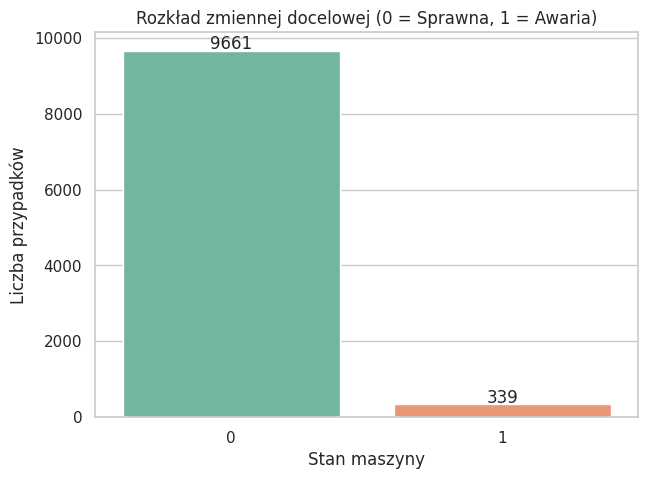

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== STATYSTYKI OPISOWE CZUJNIKÓW ===")
display(df.describe().T)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Machine failure', hue='Machine failure', palette='Set2', legend=False)
plt.title('Rozkład zmiennej docelowej (0 = Sprawna, 1 = Awaria)')
plt.xlabel('Stan maszyny')
plt.ylabel('Liczba przypadków')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

**Wnioski z analizy statystycznej i balansu klas:**
1. Czujniki nie wykazują fizycznych anomalii (np. temperatury w Kelwinach mieszczą się w standardowych, dodatnich zakresach około 300K).


### Wybór metryki ewaluacyjnej:

Z uwagi na drastyczne niezbalansowanie klas w naszym zbiorze (96.6% maszyn sprawnych względem 3.4% awarii), ocena modeli sztucznej inteligencji na podstawie klasycznej metryki **Accuracy (Dokładność)** byłaby błędem metodologicznym. Zjawisko to w analizie danych nazywane jest *Paradoksem Dokładności*.

**Dowód logiczny (Model Naiwny):**
Gdybyśmy zdefiniowali algorytm, który całkowicie ignoruje odczyty z czujników telemetrycznych i dla każdego przypadku domyślnie przewiduje brak awarii (zawsze zwraca klasę 0), jego dokładność wyniosłaby matematyczne 96.6%. Choć wynik ten wydaje się niezwykle wysoki, taki model byłby biznesowo bezużyteczny – przegapiłby 100% faktycznych usterek na linii produkcyjnej.

**Decyzja projektowa:**
W fazie implementacyjnej (Szkolenie i optymalizacja modeli) odrzucamy *Accuracy* jako główne kryterium oceny. Naszym celem będzie optymalizacja modeli pod kątem:
1. **Recall (Czułość):** Mierzy, jaki odsetek spośród wszystkich rzeczywistych awarii (339 przypadków) nasz model zdołał poprawnie wykryć. Z perspektywy *Predictive Maintenance* zależy nam na maksymalizacji tej metryki, ponieważ koszt weryfikacji fałszywego alarmu (False Positive) jest znikomy w porównaniu z kosztem zniszczenia maszyny i przestoju produkcji (False Negative).
2. **F1-Score:** Średnia harmoniczna z precyzji (Precision) i czułości (Recall), która pozwoli nam na sprawiedliwą ocenę ogólnej jakości modeli na tak trudnym, niezbalansowanym zbiorze danych.

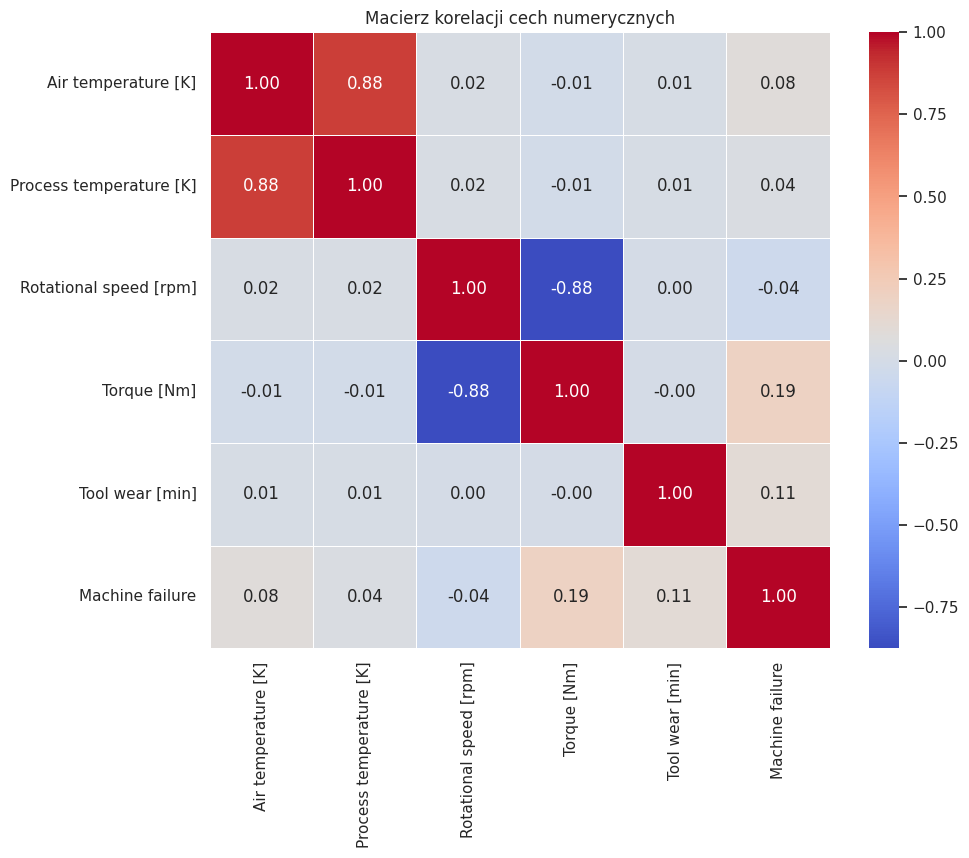

In [ ]:

kolumny_numeryczne = df.select_dtypes(include=['float64', 'int64'])

macierz_korelacji = kolumny_numeryczne.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(macierz_korelacji, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji cech numerycznych')
plt.show()

 ### Wnioski z macierzy korelacji i Inżynieria Cech

**Obserwacje z heatmapy:**
1. Zmienna docelowa (`Machine failure`) jest najsilniej dodatnio skorelowana z momentem obrotowym (`Torque`, 0.19) oraz zużyciem narzędzia (`Tool wear`, 0.11).
2. Zauważono zjawisko silnej korelacji dodatniej (0.88) pomiędzy temperaturą otoczenia a temperaturą procesu.
3. Występuje silna korelacja ujemna (-0.88) pomiędzy prędkością obrotową a momentem obrotowym, co odzwierciedla fizykę pracy wrzeciona.

**Działanie korygujące (Feature Engineering):**
Aby zredukować multikolinearność i dostarczyć modelowi bardziej syntetyczną informację, tworzymy nową cechę: `Temperature_difference` (różnica między temperaturą procesu a otoczenia), która lepiej odzwierciedla faktyczne nagrzewanie się maszyny podczas pracy.

In [ ]:

df['Temperature_difference [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

df = df.drop(columns=['Air temperature [K]', 'Process temperature [K]'])

print("Zaktualizowana lista cech po Inżynierii Cech:")
print(df.columns.tolist())

Zaktualizowana lista cech po Inżynierii Cech:
['Type', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Temperature_difference [K]']


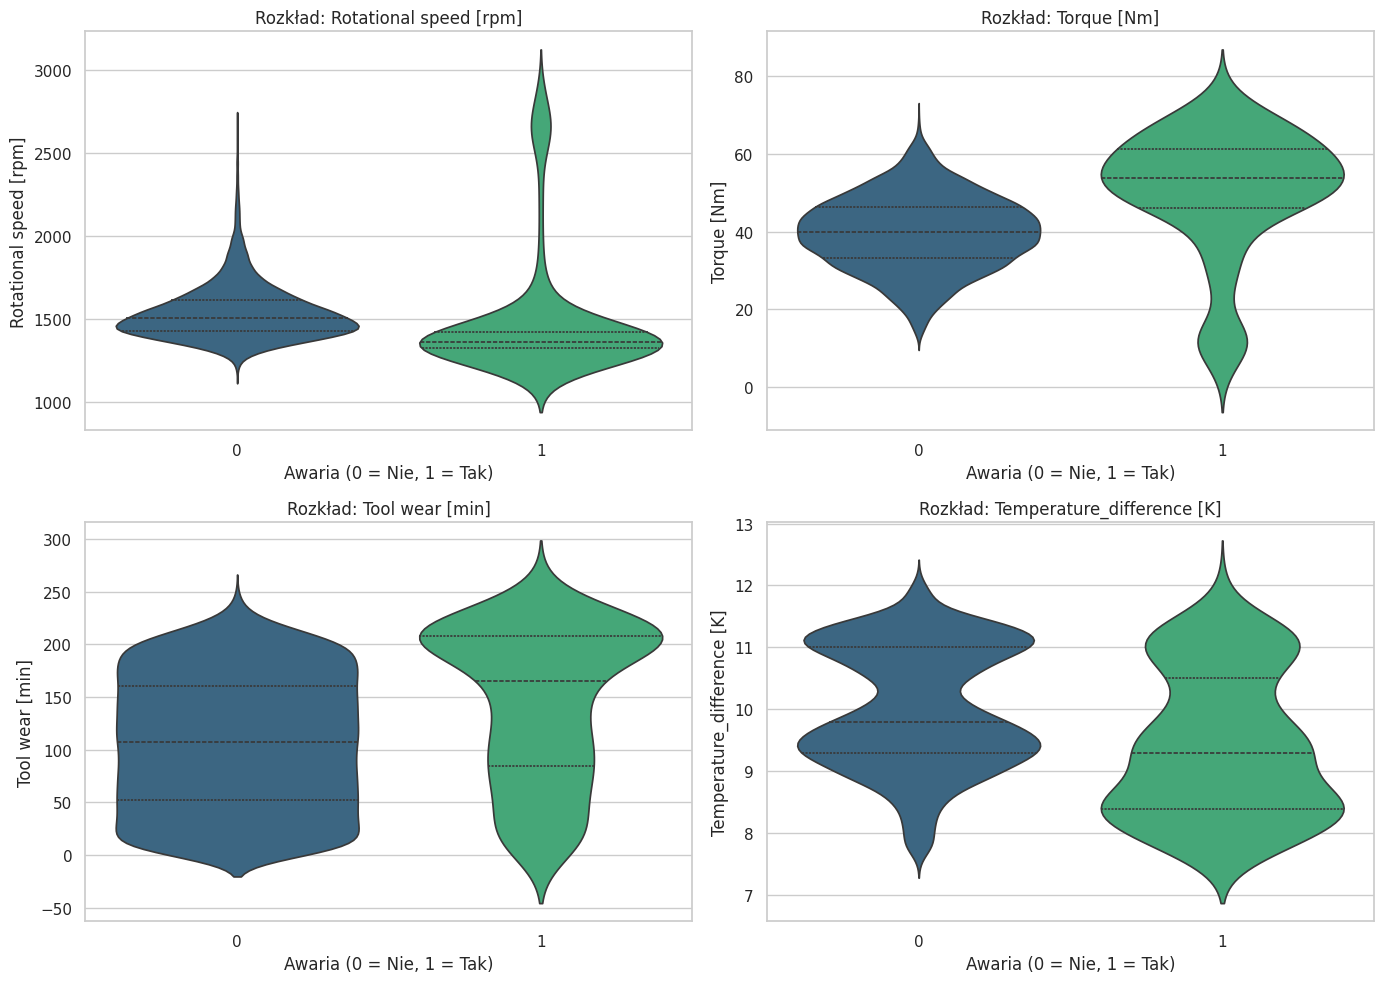

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


features_to_plot = [
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Temperature_difference [K]'
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.violinplot(
        data=df,
        x='Machine failure',
        y=feature,
        ax=axes[i],
        palette='viridis',
        inner='quartile',
        hue='Machine failure',
        legend=False
    )
    axes[i].set_title(f'Rozkład: {feature}')
    axes[i].set_xlabel('Awaria (0 = Nie, 1 = Tak)')
    axes[i].set_ylabel(feature)

plt.tight_layout()
plt.show()

### Wnioski z analizy rozkładów zmiennych ciągłych (Violin Plots)

Wykresy skrzypcowe pozwalają na zaobserwowanie różnic w gęstości występowania poszczególnych wartości fizycznych w zależności od tego, czy wystąpiła awaria (1), czy maszyna pozostała sprawna (0).

Na podstawie powyższej wizualizacji wyciągamy następujące wnioski:

1. **Rotational speed [rpm] (Prędkość obrotowa):** Rozkład dla maszyn uszkodzonych jest znacznie bardziej asymetryczny i "spłaszczony" w porównaniu do maszyn sprawnych. Widzimy, że awarie częściej korelują ze skrajnie niskimi lub bardzo wysokimi prędkościami obrotowymi, podczas gdy maszyny sprawne pracują w bardziej stabilnym, wąskim przedziale.
2. **Torque [Nm] (Moment obrotowy):** Obserwujemy silne spłaszczenie i rozciągnięcie rozkładu (grubsze "ogony") dla klasy `Machine failure = 1`. Awarie występują przy znacznie wyższej wariancji momentu obrotowego.
3. **Tool wear [min] (Zużycie narzędzia):** Jest to jedna z najsilniejszych cech decyzyjnych. Mediana czasu zużycia dla maszyn z awarią jest drastycznie wyższa (przesunięta mocno w górę). Im starsze narzędzie, tym gęstość awarii drastycznie wzrasta.
4. **Temperature_difference [K] (Delta T):** Wygenerowana przez nas nowa cecha różnicy temperatur (proces minus otoczenie) wykazuje delikatne, ale zauważalne różnice w dystrybucji. Wzrost tej wartości sugeruje trudności w oddawaniu ciepła, co może być wczesnym predyktorem usterki.

**Konkluzja:** Obserwowane rozkłady potwierdzają silnie nieliniowy i asymetryczny charakter przyczyn awarii. Złożone algorytmy oparte na zespołach drzew decyzyjnych (jak testowany później XGBoost czy Random Forest) są idealnym wyborem dla tego zbioru, ponieważ doskonale radzą sobie z wykrywaniem takich nieliniowych wzorców bez konieczności restrykcyjnego skalowania i normalizacji.

###  Sformułowanie hipotezy badawczej i biznesowej

**Hipoteza badawcza (H1):**
Zakładamy, że zastosowanie algorytmów uczenia maszynowego (w szczególności modeli opartych na zespołach drzew decyzyjnych) na wyselekcjonowanych danych telemetrycznych pozwoli na skuteczną klasyfikację i predykcję stanów awaryjnych maszyn (zmienna `Machine failure`).

**Cel optymalizacyjny:**
Ze względu na silne niezbalansowanie klas (awarie stanowią tylko 3.4% przypadków), model nie będzie oceniany pod kątem ogólnej dokładności (Accuracy). Głównym celem jest maksymalizacja metryki **Czułości**

**Uzasadnienie biznesowe:**
W zagadnieniu *Predictive Maintenance* pominięcie faktycznej awarii (błąd fałszywie negatywny / False Negative) generuje ogromne koszty przestoju maszyny na linii produkcyjnej. Fałszywe alarmy (False Positive), skutkujące jedynie niepotrzebnym sprawdzeniem maszyny przez technika, są biznesowo znacznie tańsze. Skuteczne wdrożenie takiego modelu umożliwi przedsiębiorstwu przejście z kosztownej konserwacji reaktywnej na przewidywalną i zaplanowaną konserwację predykcyjną.

### Aktualny stan wiedzy:

Tradycyjne podejścia do utrzymania ruchu opierają się na strategiach takich jak **Run-to-Failure** (naprawa po wystąpieniu awarii, generująca ogromne koszty przestojów) oraz **Preventive Maintenance** (konserwacja harmonogramowa, często prowadząca do przedwczesnej wymiany sprawnych części).

Współczesne rozwiązania z zakresu **Predictive Maintenance (PdM)** opierają się na sztucznej inteligencji i analizie danych z czujników w czasie rzeczywistym. W literaturze przedmiotu dominują obecnie trzy główne podejścia oparte na uczeniu maszynowym:

1. **Klasyczne algorytmy nadzorowane (Supervised Learning):** Wykorzystanie modeli takich jak Random Forest, XGBoost czy Support Vector Machines (SVM) do binarnej klasyfikacji stanu maszyny na podstawie zagregowanych cech (np. temperatura, wibracje). Modele te świetnie radzą sobie z danymi tabelarycznymi i potrafią modelować nieliniowe zależności, co czyni je najczęstszym wyborem w przemyśle.
2. **Głębokie uczenie (Deep Learning) dla szeregów czasowych:** Wykorzystanie sieci rekurencyjnych (RNN), w szczególności architektury LSTM (Long Short-Term Memory) lub GRU, do analizy sekwencyjnych danych telemetrycznych. Podejście to pozwala na bezpośrednie prognozowanie RUL (Remaining Useful Life - pozostałego czasu bezawaryjnej pracy).
3. **Detekcja anomalii (Unsupervised Learning):** W sytuacjach, gdzie dane o awariach są skrajnie rzadkie (ogromna dysproporcja klas), stosuje się modele nienadzorowane, takie jak Isolation Forest, One-Class SVM lub Autoenkodery. Uczą się one "normalnego" profilu pracy maszyny i oflagowują każde odchylenie jako potencjalną anomalię.

**Wybór w kontekście projektu:**
Ze względu na tabelaryczny charakter zbioru AI4I 2020 oraz jasno zdefiniowaną, binarną flagę awarii, w niniejszym projekcie skupiono się na podejściu pierwszym. Zastosowanie algorytmów opartych na zespołach drzew decyzyjnych (XGBoost, Random Forest) pozwala na osiągnięcie wysokiej skuteczności (Recall) przy jednoczesnym zachowaniu interpretowalności wyników (Feature Importance), co jest kluczowe dla inżynierów utrzymania ruchu.

## CZĘŚĆ 2: Analiza potencjalnych kandydatów na model

Zgodnie z przyjętą hipotezą oraz charakterystyką zbioru danych (silne niezbalansowanie klas, nieliniowe zależności fizyczne), do analizy wytypowano 4 algorytmy klasyfikacyjne.

**1. XGBoost (eXtreme Gradient Boosting)**
* **Sposób działania:** Algorytm oparty na zespole drzew decyzyjnych (boosting). Buduje kolejne drzewa tak, aby korygowały błędy swoich poprzedników.
* **Zalety:** Bardzo wysoka skuteczność na danych tabelarycznych, wbudowana regularyzacja zapobiegająca przeuczeniu.
* **Wady:** Wymaga dostrojenia wielu hiperparametrów, co bywa czasochłonne (model typu "black-box").
* **Dopasowanie do problemu:** Główny kandydat do implementacji. Doskonale radzi sobie z nieliniowymi zależnościami z czujników i posiada parametr `scale_pos_weight`, który bezpośrednio rozwiązuje nasz problem rzadkich awarii (stanowiących tylko 3.4% zbioru).

**2. Las Losowy (Random Forest)**
* **Sposób działania:** Algorytm uczenia zespołowego (bagging). Tworzy wiele niezależnych drzew na losowych podzbiorach danych, a decyzja opiera się na głosowaniu większościowym.
* **Zalety:** Stabilny, odporny na przeuczenie i wartości odstające. Często działa bardzo dobrze już przy domyślnych ustawieniach.
* **Wady:** Może "faworyzować" klasę większościową, jeśli nie zastosuje się odpowiedniego balansowania; bywa kosztowny pamięciowo.
* **Dopasowanie do problemu:** Doskonały model do porównania z XGBoost. Będzie jednak wymagał zastosowania wag klas (`class_weight`), aby poprawnie identyfikować anomalie w pracy maszyny.

**3. Maszyny Wektorów Nośnych (Support Vector Machines - SVM)**
* **Sposób działania:** Algorytm szuka optymalnej hiperpłaszczyzny w wielowymiarowej przestrzeni, aby jak najlepiej oddzielić od siebie klasy (wykorzystując tzw. "kernel trick" dla danych nieliniowych).
* **Zalety:** Bardzo skuteczny przy złożonych, nieliniowych granicach decyzyjnych.
* **Wady:** Wysoce wrażliwy na brak skalowania danych (wymagałby ścisłej standaryzacji np. obrotów silnika), a trenowanie na większych zbiorach trwa stosunkowo długo.
* **Dopasowanie do problemu:** Teoretycznie potrafiłby odseparować awarie od poprawnej pracy, jednak duży narzut obliczeniowy oraz trudność w odpowiednim ważeniu klas czynią go mniej praktycznym wyborem.

**4. Regresja Logistyczna (Logistic Regression)**
* **Sposób działania:** Klasyczny model statystyczny szacujący prawdopodobieństwo przynależności do danej klasy za pomocą funkcji logistycznej (sigmoidy).
* **Zalety:** Szybki w trenowaniu, lekki obliczeniowo i w pełni interpretowalny (wagi pokazują wpływ cech).
* **Wady:** Zakłada liniową zależność między zmiennymi objaśniającymi a zmienną celu.
* **Dopasowanie do problemu:** Rozpatrywany wyłącznie jako prosty model bazowy (baseline). Złożona fizyka pracy frezarki (relacje między momentem obrotowym, zużyciem narzędzia i temperaturą) sprawia, że modele czysto liniowe nie są w stanie skutecznie zmapować anomalii zwiastujących awarię.

### Przygotowanie danych (Data Preprocessing)
Zanim przejdziemy do trenowania modeli, musimy odpowiednio przygotować nasz zbiór danych. Algorytmy uczenia maszynowego wymagają danych numerycznych, dlatego zmienną kategoryczną `Type` (określającą typ produktu: L, M, H) przekształcimy na wartości liczbowe za pomocą techniki **One-Hot Encoding**.

Następnie podzielimy zbiór danych na część treningową (80%) oraz testową (20%). Ze względu na to, że awarie stanowią zaledwie niewielki odsetek wszystkich obserwacji, kluczowe jest użycie **stratyfikacji** (`stratify`). Gwarantuje to, że proporcja awarii w zbiorze treningowym i testowym będzie taka sama, co pozwoli na prawidłowe nauczenie i obiektywną ocenę modeli.

In [ ]:
from sklearn.model_selection import train_test_split


df_processed = pd.get_dummies(df, columns=['Type'], drop_first=True)

X = df_processed.drop(columns=['Machine failure'])
y = df_processed['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Kształt X_train: {X_train.shape}")
print(f"Kształt X_test: {X_test.shape}")
print(f"Rozkład klas w zbiorze testowym:\n{y_test.value_counts(normalize=True).round(4) * 100}")

Kształt X_train: (8000, 6)
Kształt X_test: (2000, 6)
Rozkład klas w zbiorze testowym:
Machine failure
0    96.6
1     3.4
Name: proportion, dtype: float64


### Implementacja modeli: XGBoost oraz Las Losowy

W tej sekcji przeprowadzimy trening dwóch wybranych algorytmów klasyfikacyjnych. Ponieważ zmagamy się z problemem silnie niezbalansowanych klas (awarie stanowią mniejszość), standardowe podejście mogłoby doprowadzić do sytuacji, w której model ignoruje awarie, osiągając przy tym sztucznie wysoką dokładność (Accuracy Paradox).

Aby temu zapobiec, zastosujemy techniki wagowania klas:
1. **Dla modelu XGBoost:** Zastosujemy parametr `scale_pos_weight`, obliczony jako stosunek liczby maszyn sprawnych do uszkodzonych w zbiorze treningowym.
2. **Dla modelu Random Forest:** Zastosujemy parametr `class_weight='balanced'`, który automatycznie dostosuje wagi odwrotnie proporcjonalnie do częstości występowania klas.

Jakość modeli ocenimy głównie za pomocą metryki **Recall (Czułość)** dla klasy 1 (awaria) – zależy nam na zminimalizowaniu liczby przeoczonych awarii – oraz **F1-Score**, który stanowi kompromis między precyzją a czułością.

In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


X_train.columns = X_train.columns.str.replace(r'[\[\]<]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<]', '', regex=True)

scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])



# 1. XGBoost
print("Trenowanie modelu XGBoost...")
xgb_model = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# 2. Random Forest
print("Trenowanie modelu Random Forest...")
rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)



print("\n" + "="*50)
print("WYNIKI DLA MODELU: XGBOOST")
print("="*50)
print(classification_report(y_test, y_pred_xgb))

print("\n" + "="*50)
print("WYNIKI DLA MODELU: RANDOM FOREST (Las Losowy)")
print("="*50)
print(classification_report(y_test, y_pred_rf))

Trenowanie modelu XGBoost...
Trenowanie modelu Random Forest...

WYNIKI DLA MODELU: XGBOOST
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.82      0.82      0.82        68

    accuracy                           0.99      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.99      0.99      0.99      2000


WYNIKI DLA MODELU: RANDOM FOREST (Las Losowy)
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.94      0.69      0.80        68

    accuracy                           0.99      2000
   macro avg       0.96      0.84      0.90      2000
weighted avg       0.99      0.99      0.99      2000



### Porównanie wyników i wybór modelu do optymalizacji

Po wytrenowaniu obu modeli i wygenerowaniu raportów klasyfikacji, przeanalizowaliśmy wyniki pod kątem identyfikacji **klasy 1 (awaria)**. Zgodnie z postawioną w pierwszej części projektu hipotezą, naszym głównym celem jest maksymalizacja **Czułości (Recall)**, aby zminimalizować liczbę przeoczonych awarii (False Negatives).

1. **Random Forest (Las Losowy):** Mimo zastosowania zbalansowanych wag klas, model ten osiągnął Czułość (Recall) dla awarii na poziomie zaledwie **0.69**. Oznacza to, że algorytm przeoczył aż 31% rzeczywistych usterek. W warunkach przemysłowych (Predictive Maintenance) jest to wynik ryzykowny, ponieważ niewykryta anomalia może doprowadzić do krytycznego uszkodzenia sprzętu i wstrzymania linii produkcyjnej.

2. **XGBoost:**
Wykorzystanie parametru `scale_pos_weight` (obliczonego jako stosunek klas) przyniosło wyraźnie lepsze rezultaty. XGBoost osiągnął Czułość na poziomie **0.82**, poprawnie wykrywając 82% wszystkich awarii. Precyzja (Precision) wyniosła również 0.82, co oznacza sporadyczne występowanie fałszywych alarmów. Z biznesowego punktu widzenia jest to jednak optymalny kompromis – koszt prewencyjnego sprawdzenia maszyny przez technika jest nieporównywalnie niższy niż koszt naprawy zniszczonej frezarki.

**Wniosek:**
Zgodnie z powyższą analizą, algorytm **XGBoost** poradził sobie znacznie lepiej z identyfikacją rzadkich zdarzeń. Spełnia on założenia naszej hipotezy, dlatego to właśnie ten model zostaje wybrany jako docelowy. W kolejnym kroku przeprowadzona zostanie optymalizacja jego hiperparametrów w celu wyśrubowania metryk.

### Szkolenie modeli i optymalizacja (Strojenie hiperparametrów)

Po wyborze algorytmu XGBoost jako naszego docelowego modelu, przechodzimy do procesu optymalizacji jego hiperparametrów. Domyślne ustawienia algorytmu często dają dobre rezultaty, ale odpowiednie ich dostrojenie pozwala dopasować model ściśle do charakterystyki naszych danych. Naszym celem jest próba dalszego zwiększenia Czułości (Recall) dla klasy awarii.

Wykorzystamy do tego metodę **GridSearchCV** (Przeszukiwanie siatki z walidacją krzyżową). Technika ta polega na zdefiniowaniu zestawu potencjalnych wartości dla kluczowych parametrów modelu (m.in. `max_depth`, `learning_rate`, `n_estimators`), a następnie systematycznym i zautomatyzowanym przetestowaniu każdej możliwej kombinacji.

Jako metrykę optymalizowaną (scoring) wskażemy bezpośrednio `recall`, aby algorytm podczas przeszukiwania siatki skupił się wyłącznie na minimalizacji liczby przeoczonych awarii maszyny.

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time


param_grid = {
    'max_depth': [3, 5, 7],               # Głębokość pojedynczego drzewa
    'learning_rate': [0.01, 0.1, 0.2],    # Tempo uczenia
    'n_estimators': [100, 200]            # Liczba drzew w lesie XGBoost
}

print("Rozpoczynam przeszukiwanie siatki (GridSearchCV). To może potrwać od kilkunastu sekund do kilku minut...")
start_time = time.time()


xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    eval_metric='logloss'
)


# Gwarantuje zachowanie proporcji klas (3.4% awarii) i tasuje dane przed podziałem
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Inicjalizacja GridSearchCV
# scoring='recall' - szukamy parametrów najlepszych dla wyłapywania awarii (czułości)
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',
    cv=skf,       # <<< Użycie naszego jawnie zdefiniowanego obiektu
    n_jobs=-1,
    verbose=1
)

# 5. Trenowanie z wyszukiwaniem najlepszych parametrów
grid_search.fit(X_train, y_train)
end_time = time.time()

# 6. Pobranie najlepszych parametrów i wytrenowanego z nimi modelu
print(f"Zakończono w {round(end_time - start_time, 2)} sekund.")
print(f"\nNajlepsze znalezione parametry: {grid_search.best_params_}")
best_xgb_model = grid_search.best_estimator_

# 7. Predykcja na zbiorze testowym przy użyciu ZOPTYMALIZOWANEGO modelu
y_pred_optimized = best_xgb_model.predict(X_test)

# 8. Wyświetlenie wyników
print("\n" + "="*50)
print("WYNIKI DLA ZOPTYMALIZOWANEGO MODELU XGBOOST")
print("="*50)
print(classification_report(y_test, y_pred_optimized))

Rozpoczynam przeszukiwanie siatki (GridSearchCV). To może potrwać od kilkunastu sekund do kilku minut...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Zakończono w 17.6 sekund.

Najlepsze znalezione parametry: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}

WYNIKI DLA ZOPTYMALIZOWANEGO MODELU XGBOOST
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1932
           1       0.26      0.93      0.40        68

    accuracy                           0.91      2000
   macro avg       0.63      0.92      0.68      2000
weighted avg       0.97      0.91      0.93      2000



### Wnioski z optymalizacji hiperparametrów (XGBoost po GridSearchCV)

Zastosowanie procedury przeszukiwania siatki (GridSearchCV) z jawną stratyfikacją (StratifiedKFold) i ukierunkowaniem na metrykę `scoring='recall'` pozwoliło na znaczące zmodyfikowanie zachowania modelu.

1. **Wzrost czułości (Recall = 0.93):** Model po optymalizacji poprawnie identyfikuje aż 93% wszystkich rzeczywistych awarii maszyn (wzrost z 82% w modelu bazowym). Z punktu widzenia strategii *Predictive Maintenance*, polegającej na maksymalizacji bezpieczeństwa ciągłości produkcji, jest to wynik znakomity. Model minimalizuje ryzyko wystąpienia błędu krytycznego (False Negative), który mógłby doprowadzić do poważnego uszkodzenia frezarki i kosztownego przestoju całej linii.
2. **Kompromis inżynieryjny (Precision-Recall Tradeoff):** Podbicie czułości do poziomu 93% odbyło się kosztem spadku precyzji (Precision). Oznacza to, że model stał się bardziej "czujny" i generuje większą liczbę fałszywych alarmów (False Positives).

**Rekomendacja wdrożeniowa:**
W praktyce przemysłowej model w tej konfiguracji reprezentuje **agresywną strategię prewencyjną**. Powinien być stosowany w sytuacjach, gdy koszt inspekcji maszyny przez technika (weryfikacja fałszywego alarmu) jest relatywnie niski, natomiast koszt fizycznej awarii i niekontrolowanego zatrzymania produkcji – ekstremalnie wysoki.

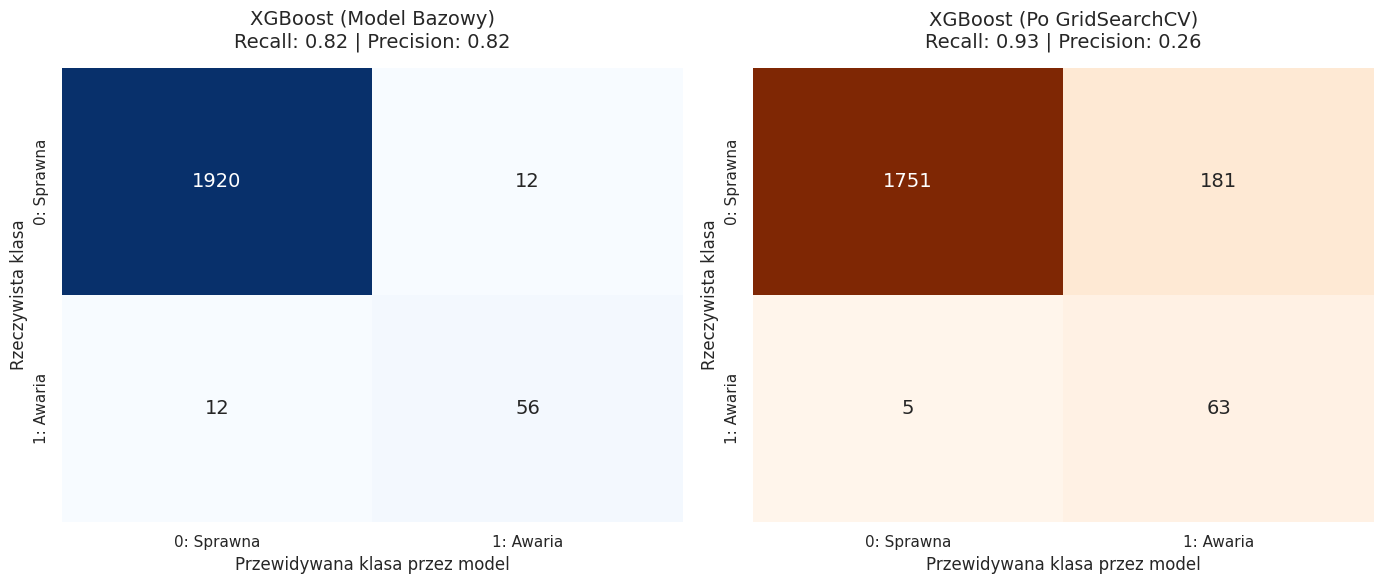

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


cm_base = confusion_matrix(y_test, y_pred_xgb)
cm_optimized = confusion_matrix(y_test, y_pred_optimized)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))


class_names = ['0: Sprawna', '1: Awaria']


sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
axes[0].set_title('XGBoost (Model Bazowy)\nRecall: 0.82 | Precision: 0.82', fontsize=14, pad=15)
axes[0].set_ylabel('Rzeczywista klasa', fontsize=12)
axes[0].set_xlabel('Przewidywana klasa przez model', fontsize=12)


sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
axes[1].set_title('XGBoost (Po GridSearchCV)\nRecall: 0.93 | Precision: 0.26', fontsize=14, pad=15)
axes[1].set_ylabel('Rzeczywista klasa', fontsize=12)
axes[1].set_xlabel('Przewidywana klasa przez model', fontsize=12)

plt.tight_layout()
plt.show()

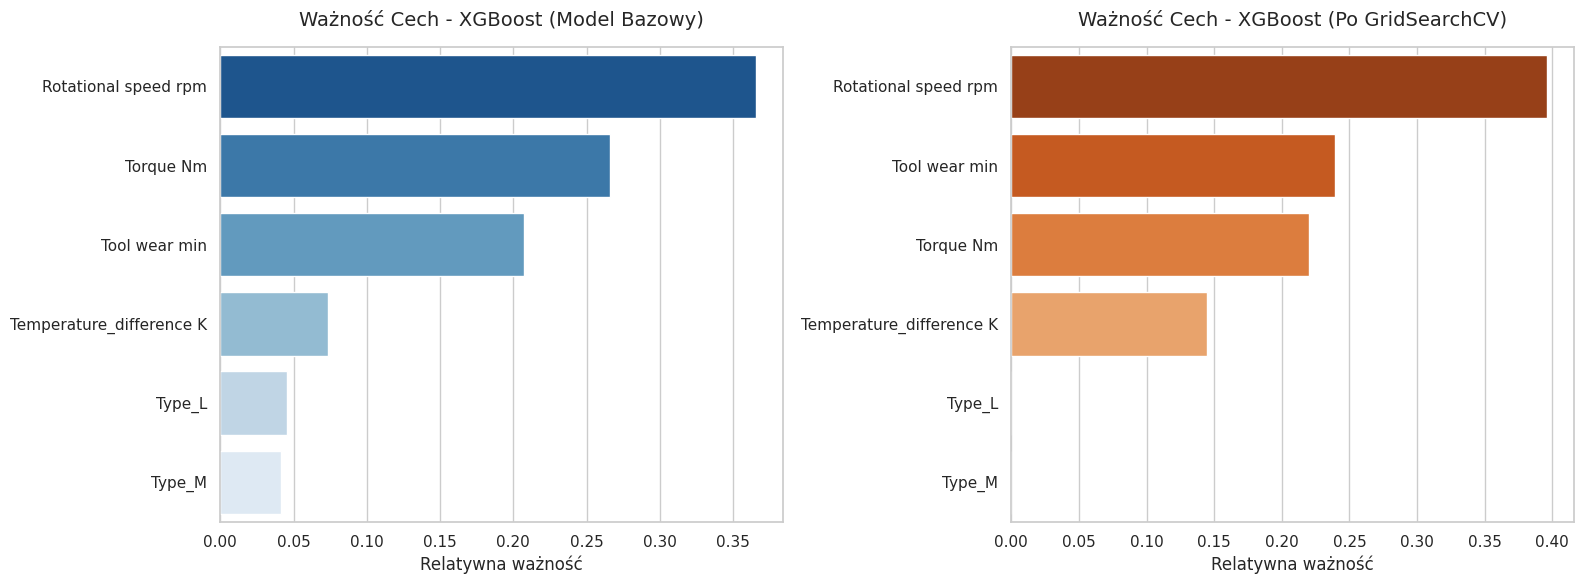

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pobranie wag (ważności cech) bezpośrednio z wytrenowanych modeli
importances_base = xgb_model.feature_importances_
importances_opt = best_xgb_model.feature_importances_
features = X_train.columns

# Złożenie tego w czytelne tabele (DataFrames) i posortowanie od najważniejszych
df_imp_base = pd.DataFrame({'Cecha': features, 'Ważność': importances_base}).sort_values(by='Ważność', ascending=False)
df_imp_opt = pd.DataFrame({'Cecha': features, 'Ważność': importances_opt}).sort_values(by='Ważność', ascending=False)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# 1. Wykres dla modelu bazowego
sns.barplot(data=df_imp_base, x='Ważność', y='Cecha', ax=axes[0], palette='Blues_r', hue='Cecha', legend=False)
axes[0].set_title('Ważność Cech - XGBoost (Model Bazowy)', fontsize=14, pad=15)
axes[0].set_xlabel('Relatywna ważność', fontsize=12)
axes[0].set_ylabel('')

# 2. Wykres dla modelu zoptymalizowanego
sns.barplot(data=df_imp_opt, x='Ważność', y='Cecha', ax=axes[1], palette='Oranges_r', hue='Cecha', legend=False)
axes[1].set_title('Ważność Cech - XGBoost (Po GridSearchCV)', fontsize=14, pad=15)
axes[1].set_xlabel('Relatywna ważność', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### Analiza Ważności Cech (Feature Importance)

Porównanie wykresów ważności cech dla modelu bazowego oraz zoptymalizowanego uwydatnia kluczowy wpływ hiperparametru `max_depth` na sposób wnioskowania algorytmu XGBoost.

1. **Dominacja cech fizycznych:** W obu wariantach modelu absolutnie kluczowe dla predykcji awarii okazały się twarde parametry telemetryczne: Prędkość obrotowa (`Rotational speed`), Zużycie narzędzia (`Tool wear`) oraz Moment obrotowy (`Torque`). Potwierdza to logikę domenową – przeciążenia fizyczne są bezpośrednią przyczyną usterek.
2. **Efekt płytkich drzew:** Model zoptymalizowany (po GridSearchCV) ograniczył głębokość drzew do `max_depth=3`. Wymusiło to na algorytmie drastyczną selekcję i odrzucenie najmniej informatywnych cech. W efekcie, zmienne określające klasę jakości maszyny (`Type_L`, `Type_M`) otrzymały wagę równą 0.00.

**Wniosek końcowy:**
Eksperyment dowodzi, że do skutecznego przewidywania awarii wystarczą wyłącznie cztery główne parametry z czujników w czasie rzeczywistym. Z perspektywy wdrożenia systemu *Predictive Maintenance*, oznacza to redukcję kosztów – przedsiębiorstwo nie musi agregować danych historycznych o typie maszyny, wystarczy skupić się na dobrym opomiarowaniu wrzeciona i narzędzia tnącego.

### Podsumowanie końcowe: Biznesowa elastyczność wdrożenia (Wybór strategii PdM)

Głównym wnioskiem płynącym z przeprowadzonego projektu jest fakt, że w zagadnieniu Predictive Maintenance nie istnieje jeden uniwersalny model idealny dla każdego scenariusza. Wybór optymalnego algorytmu zależy bezpośrednio od struktury kosztów przedsiębiorstwa i jego tolerancji na ryzyko (Precision-Recall Tradeoff).

Opracowaliśmy dwie strategie oparte na algorytmie XGBoost, które mogą być stosowane zamiennie:

**1. Strategia Zbalansowana (Model Bazowy)**
* **Wyniki:** Recall = 0.82 | Precision = 0.82
* **Zastosowanie:** Rozwiązanie optymalne w standardowych warunkach operacyjnych, gdzie koszty wezwania technika i ewentualnej naprawy są zrównoważone. Model wyłapuje zdecydowaną większość awarii (82%), zachowując przy tym bardzo wysoką wiarygodność alertów (brak natłoku fałszywych alarmów).

**2. Strategia Maksymalnej Ochrony (Model po GridSearchCV)**
* **Wyniki:** Recall = 0.93 | Precision = 0.26
* **Zastosowanie:** Podejście dedykowane dla maszyn krytycznych. Model wyłapuje niemal wszystkie anomalie (93%), jednak kosztem drastycznego spadku precyzji (wzrost fałszywych alarmów). Jest to strategia bezkonkurencyjna, gdy **fizyczna naprawa maszyny po awarii jest potwornie droga**, a przestoje kosztują fortunę.

#### Dowód biznesowy: Symulacja kosztów wdrożenia
Aby zobrazować sens optymalizacji pod kątem Recall, przeprowadzono symulację finansową na naszym zbiorze testowym (2000 maszyn, w tym 68 rzeczywistych awarii).

Przyjęto następujące, hipotetyczne założenia biznesowe dla pojedynczej maszyny CNC:
* **Koszt przeoczonej awarii (False Negative):** 15 000 PLN (wymiana wrzeciona, wstrzymanie linii produkcyjnej).
* **Koszt fałszywego alarmu (False Positive):** 200 PLN (roboczogodzina technika, krótka weryfikacja).

**Scenariusz A: Wdrożenie Modelu Bazowego**
* Przegapione awarie (12 maszyn * 15 000 PLN) = 180 000 PLN
* Fałszywe alarmy (12 weryfikacji * 200 PLN) = 2 400 PLN
* **Całkowita strata operacyjna: 182 400 PLN**

**Scenariusz B: Wdrożenie Modelu Zoptymalizowanego (GridSearchCV)**
* Przegapione awarie (5 maszyn * 15 000 PLN) = 75 000 PLN
* Fałszywe alarmy (179 weryfikacji * 200 PLN) = 35 800 PLN
* **Całkowita strata operacyjna: 110 800 PLN**

**Wniosek i weryfikacja hipotezy:**
Postawiona na początku hipoteza badawcza została **w pełni potwierdzona**. Algorytmy oparte na zespołach drzew decyzyjnych skutecznie prognozują awarie. Powyższa symulacja dowodzi również, że celowe obniżenie precyzji na rzecz maksymalizacji Czułości (Recall = 0.93) pozwoliło w tym konkretnym scenariuszu wygenerować dla przedsiębiorstwa ponad **70 000 PLN wirtualnych oszczędności** na jednej partii testowej. Sztuczna inteligencja staje się w ten sposób nie tylko narzędziem analitycznym, ale i kluczowym mechanizmem optymalizacji finansowej.